# QeVAE

Reimplements the core model from [Anantha-Rao12/Quantum-enhanced-variational-autoencoder](https://github.com/Anantha-Rao12/Quantum-enhanced-variational-autoencoder)
(the QeVAE of *"Learning hard distributions with quantum-enhanced Variational Autoencoders"*,
[arXiv:2305.01592](https://arxiv.org/abs/2305.01592)), mirroring the structure of `vae.ipynb` /
`svae.ipynb` / `qvae.ipynb` (data → model → train → sample → reconstructions → interpolations).

Unlike the fully-quantum autoencoder in `qvae.ipynb` (gersteinlab/QVAE — unitary encoder, trash-qubit
bottleneck, unitary decoder, all on density matrices), the QeVAE is a **hybrid classical–quantum VAE
that learns a probability distribution over measurement bitstrings**. A *classical* neural-network
encoder maps a measurement vector to a Gaussian latent; a linear preprocessor turns a latent sample
into circuit angles; and a *quantum* parameterized circuit decoder outputs a full probability
distribution over the `2^n` computational-basis bitstrings. The training signal is the negative
log-likelihood the decoder assigns to the data, plus the usual KL-to-standard-normal.

The official repo (`Sourcecode/QeVAE.py`, `Model_learndist.py`, `Auxillary_functions.py`, `main.py`)
is a Qiskit 0.x / `qiskit-machine-learning` research script: the decoder is a `CircuitQNN` (a
`ZFeatureMap` feature map + a `TwoLocal` `ry`/`rx`/`cx` ansatz) wrapped in a `TorchConnector` and run
on the `qasm_simulator`, trained with two Adam optimizers (one classical, one quantum via
parameter-shift), tied to its own 4-/8-qubit quantum-state datasets and a file-based CLI. It is not
pip-installable against current Qiskit and predates this survey's MNIST/PyTorch baseline, so instead
of importing it directly this notebook ports its load-bearing pieces — the classical
encoder / reparameterization / linear preprocessor (`Model_learndist.py::QeVAE_model`), the
`ZFeatureMap` + `TwoLocal` circuit decoder (`Model_learndist.py::create_qnn`), and the
NLL-reconstruction + KL objective (`QeVAE.py::QeVAE.train`) — as plain `torch` ops, wired into the
same MNIST pipeline used elsewhere in this survey. The decoder circuit is simulated as a
**differentiable batched statevector** (`|<b|psi>|^2` reproduces the `CircuitQNN` output
probabilities in the shot→∞ limit), so — as in `qvae.ipynb` — we train the whole thing with a single
Adam over autograd gradients instead of the original parameter-shift `CircuitQNN`, a practical swap
that leaves the model's math unchanged.

In [1]:
import math
import pathlib
import sys

import torch
import torch.nn as nn
import torchvision.datasets as datasets

for _root in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_root / "vae" / "models").is_dir():
        sys.path.insert(0, str(_root))
        break

from vae.models.qevae import QeVAE
from vae.handlers.qevae import (
    to_distributions,
    to_marginals,
    reconstruction_loss,
    kl_divergence,
    dist_to_image,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float64)  # statevector/gate math is numerically sensitive

## Data

Same MNIST split used by `vae.ipynb`, but — since the QeVAE learns a *probability distribution over
bitstrings* rather than pixel intensities or amplitudes — each image is turned into a distribution
over the `2^n` computational-basis states. Simulating dense quantum circuits is exponential in qubit
count, so, matching the original repo's small 4-/8-qubit inputs and mirroring `qvae.ipynb`, we
downsample each 28x28 image to 8x8 = 64 = 2^6 pixels (`n_qubit=6`) and L1-normalize each flattened
image so it sums to 1. A normalized image `p_x` is then a valid distribution over the 64 bitstrings;
reshaping it back to 8x8 recovers the picture (this is how the decoder's output is read as an image
too).

The QeVAE encoder consumes a length-`n` measurement vector (`Linear(n_qubit, 8)` in
`QeVAE_model`). The faithful per-image analogue of "a measurement of the state" here is the vector of
**per-qubit marginals** — `P(qubit i = 1)` under `p_x`, i.e. the expected value of each single-qubit
measurement — a length-`n_qubit` summary that gives every image a distinct encoder input while
keeping the encoder's ported input dimension exactly as in the repo.

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

n_qubit = 6
res = 2 ** (n_qubit // 2)   # 8x8 = 64 = 2^6
n_states = 2 ** n_qubit

train_dist = to_distributions(mnist_trainset.data[:-10000])
eval_dist = to_distributions(mnist_trainset.data[-10000:])
train_marg = to_marginals(train_dist)
eval_marg = to_marginals(eval_dist)

## Quantum-circuit decoder (statevector)

Ported from `Model_learndist.py::create_qnn`. The decoder is a `ZFeatureMap` that embeds the
preprocessed latent as single-qubit rotation angles, followed by a `TwoLocal` variational ansatz
(`rotation_blocks=["ry","rx"]`, `entanglement_blocks="cx"`, linear entanglement). The original builds
this with Qiskit and evaluates it as a `CircuitQNN` on the `qasm_simulator`; here we simulate it as a
batched statevector starting from `|0...0>`, applying each gate by contracting the relevant qubit
axis, and read the output distribution as `|<b|psi>|^2` — exactly the probabilities the `CircuitQNN`
returns, but fully differentiable so autograd (not parameter-shift) supplies the gradients.

## Model

Ported from `Model_learndist.py::QeVAE_model`. A classical encoder (`Linear(n_qubit, 8)` → LeakyReLU →
`Linear(8, 7)` → LeakyReLU) feeds two heads `z_mean` / `z_log_var`; a latent is drawn by the
reparameterization trick; a linear `preprocessor` (small-normal weights, zero bias, exactly as in the
repo) maps the latent to the `n_qubit` circuit input angles; and the quantum decoder above turns those
angles into a distribution over the `2^n` bitstrings. The only trainable *quantum* parameters are the
`TwoLocal` ansatz weights (`decoder_theta`), which stand in for the repo's `TorchConnector` weights.

## Objective: negative log-likelihood + KL

Ported from `QeVAE.py::QeVAE.train`. The repo's reconstruction term is the NLL the decoder assigns to
the single input bitstring, `-log q(b_data)` (with its smoothing `(q + 2^-18) / (1 + 2^-18 * 2^n)` to
keep the log finite). Since each MNIST image here is a *distribution* `p_x` over bitstrings rather than
one sample, the faithful batched generalization is the cross-entropy `-Σ_b p_x(b) log q(b)`, which is
exactly the expectation of the repo's per-sample loss over `b ~ p_x` (and reduces to it when `p_x` is a
one-hot). The KL term is the repo's `-0.5 * Σ (1 + logσ² - μ² - σ²)`; `beta` is linearly annealed from
0 to 1, matching the annealing used across this survey.

## Training

Batched over the bitstring distributions built from the downsampled images.
Simulating the decoder circuit gate-by-gate is the dominant cost and is roughly independent of batch
size, so — as in `qvae.ipynb` — more steps matters more than a bigger batch. MNIST is much larger than
the original repo's few-thousand-row quantum-state datasets, so instead of iterating over all 50000
images each epoch, every "epoch" draws one fresh random subset of `steps_per_epoch * batch_size`
images. Increase `steps_per_epoch` / `num_epochs` for a better-trained model once you've confirmed the
loss is going down.

In [3]:
model = QeVAE(n_qubit=n_qubit, latent_dim=4, fm_reps=2, ansatz_reps=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 5        # Change this to train the model a bit more
steps_per_epoch = 100  # Change this to train on more data per epoch
batch_size = 32
beta_max = 1.0
log_every = 10

train_p = train_dist.to(device)
train_m = train_marg.to(device)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        idx = torch.randint(0, len(train_p), (batch_size,), device=device)
        target = train_p[idx]
        enc_in = train_m[idx]

        progress = (epoch * steps_per_epoch + step) / (num_epochs * steps_per_epoch)
        beta = min(beta_max, progress * 2)

        recon, z_mean, z_log_var = model(enc_in)
        recon_l = reconstruction_loss(recon, target)
        kl_l = kl_divergence(z_mean, z_log_var)
        loss = recon_l + beta * kl_l

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (step + 1) % log_every == 0:
            print(f"  epoch {epoch + 1}/{num_epochs}  step {step + 1}/{steps_per_epoch}  "
                  f"recon_loss={recon_l.item():.4f}  kl={kl_l.item():.4f}")

    print(f"epoch {epoch + 1}/{num_epochs}  avg loss={epoch_loss / steps_per_epoch:.4f}")

  epoch 1/5  step 10/100  recon_loss=7.4989  kl=0.1999
  epoch 1/5  step 20/100  recon_loss=5.7953  kl=0.6204
  epoch 1/5  step 30/100  recon_loss=4.9600  kl=1.4812


  epoch 1/5  step 40/100  recon_loss=4.6693  kl=0.9018
  epoch 1/5  step 50/100  recon_loss=4.3742  kl=0.5499
  epoch 1/5  step 60/100  recon_loss=4.2199  kl=0.5625


  epoch 1/5  step 70/100  recon_loss=4.1559  kl=0.5515
  epoch 1/5  step 80/100  recon_loss=3.9607  kl=0.3906
  epoch 1/5  step 90/100  recon_loss=3.9832  kl=0.2190


  epoch 1/5  step 100/100  recon_loss=3.8352  kl=0.1479
epoch 1/5  avg loss=5.1086
  epoch 2/5  step 10/100  recon_loss=3.7358  kl=0.0712
  epoch 2/5  step 20/100  recon_loss=3.6519  kl=0.0254


  epoch 2/5  step 30/100  recon_loss=3.6519  kl=0.0010
  epoch 2/5  step 40/100  recon_loss=3.6577  kl=0.0020
  epoch 2/5  step 50/100  recon_loss=3.5926  kl=0.0002


...

  epoch 4/5  step 70/100  recon_loss=3.4162  kl=0.0000
  epoch 4/5  step 80/100  recon_loss=3.4078  kl=0.0000
  epoch 4/5  step 90/100  recon_loss=3.4963  kl=0.0000


  epoch 4/5  step 100/100  recon_loss=3.3770  kl=0.0000
epoch 4/5  avg loss=3.4179
  epoch 5/5  step 10/100  recon_loss=3.4402  kl=0.0000
  epoch 5/5  step 20/100  recon_loss=3.4137  kl=0.0000


  epoch 5/5  step 30/100  recon_loss=3.3679  kl=0.0000
  epoch 5/5  step 40/100  recon_loss=3.3993  kl=0.0000
  epoch 5/5  step 50/100  recon_loss=3.4249  kl=0.0000


  epoch 5/5  step 60/100  recon_loss=3.4114  kl=0.0000
  epoch 5/5  step 70/100  recon_loss=3.4623  kl=0.0000
  epoch 5/5  step 80/100  recon_loss=3.4575  kl=0.0000


  epoch 5/5  step 90/100  recon_loss=3.4000  kl=0.0000
  epoch 5/5  step 100/100  recon_loss=3.3685  kl=0.0000
epoch 5/5  avg loss=3.4050


## Visualizing samples

Mirrors `sample()` / `Decoder_distribution` in the repo: draw a latent from the standard-normal prior,
push it through the preprocessor and quantum decoder, and read the resulting `2^n` distribution back
as an 8x8 image.

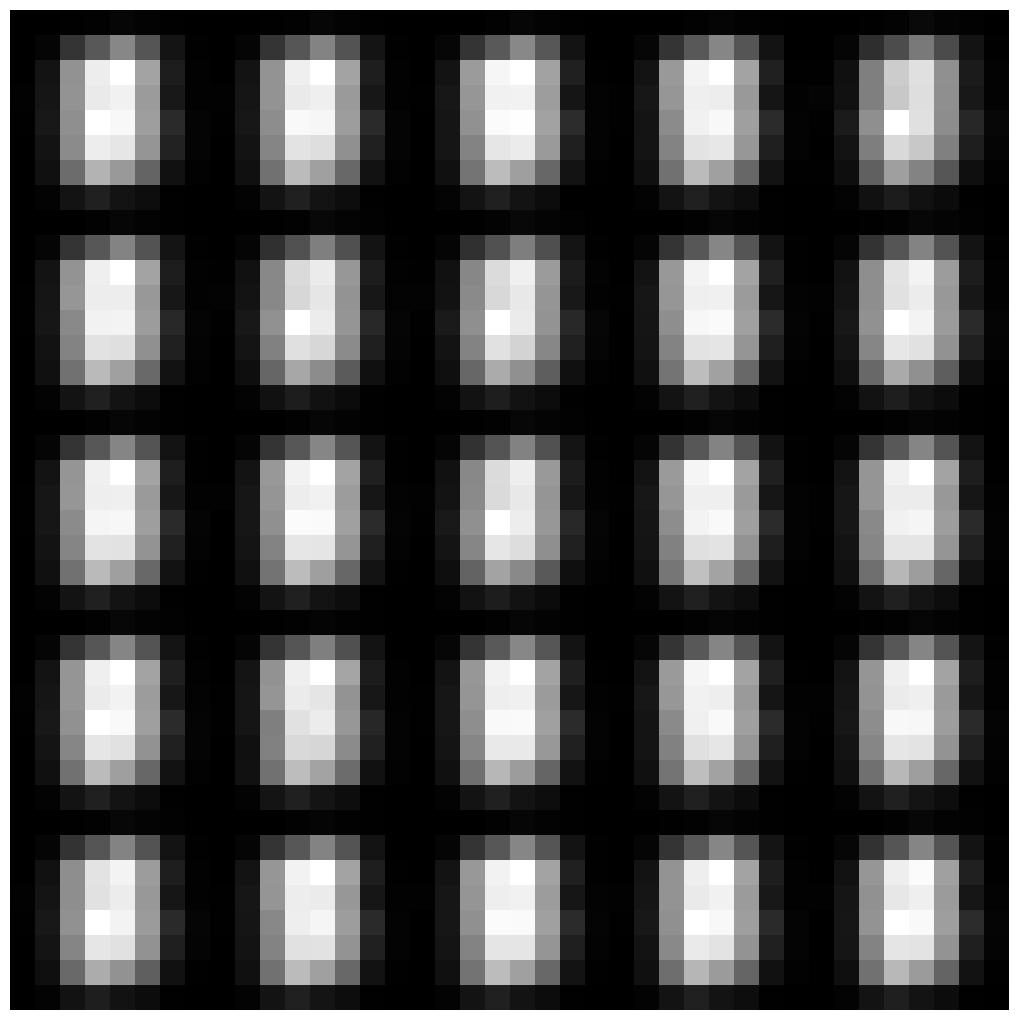

In [4]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    z = torch.randn(25, model.latent_dim, device=device)
    gen_data = dist_to_image(model.decode(z)).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

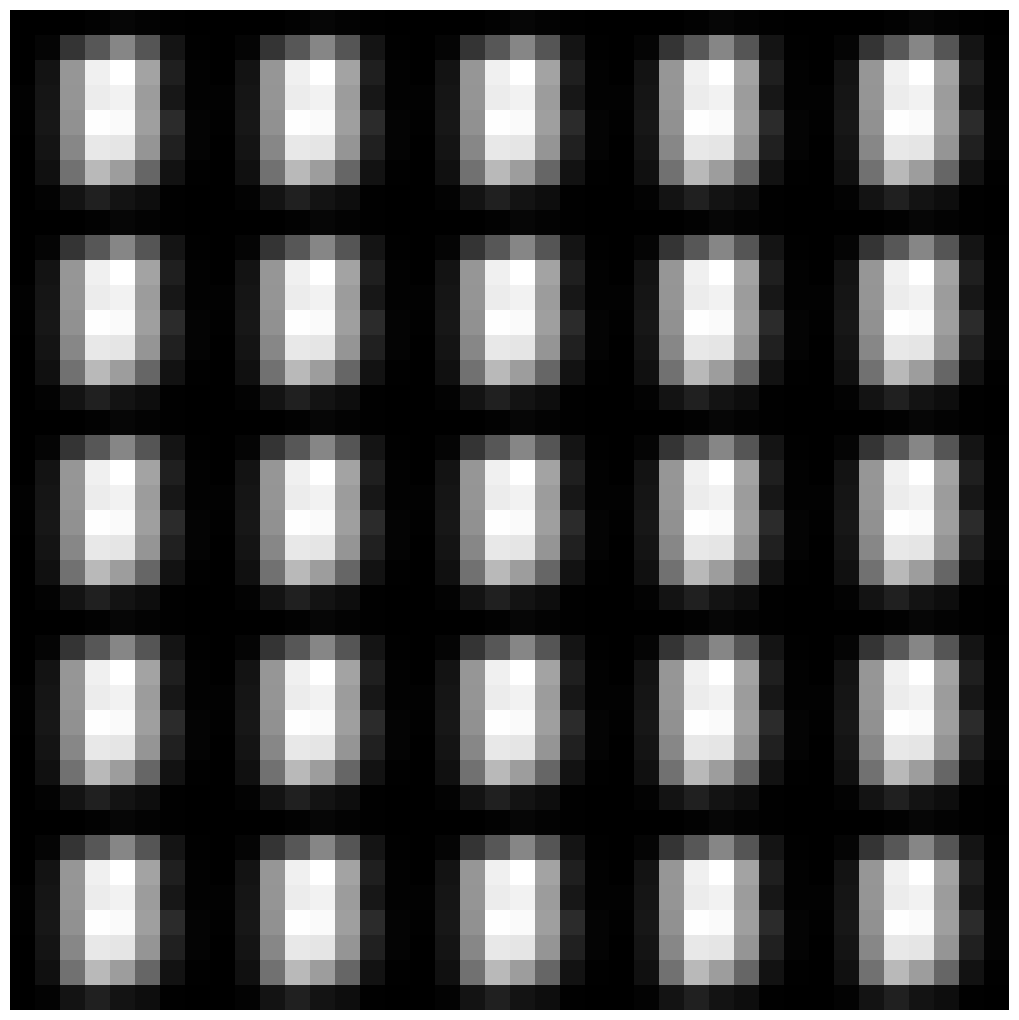

In [5]:
eval_in = eval_marg[:25].to(device)
with torch.no_grad():
    z = model.encode_mean(eval_in)
    reconstructions = dist_to_image(model.decode(z)).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

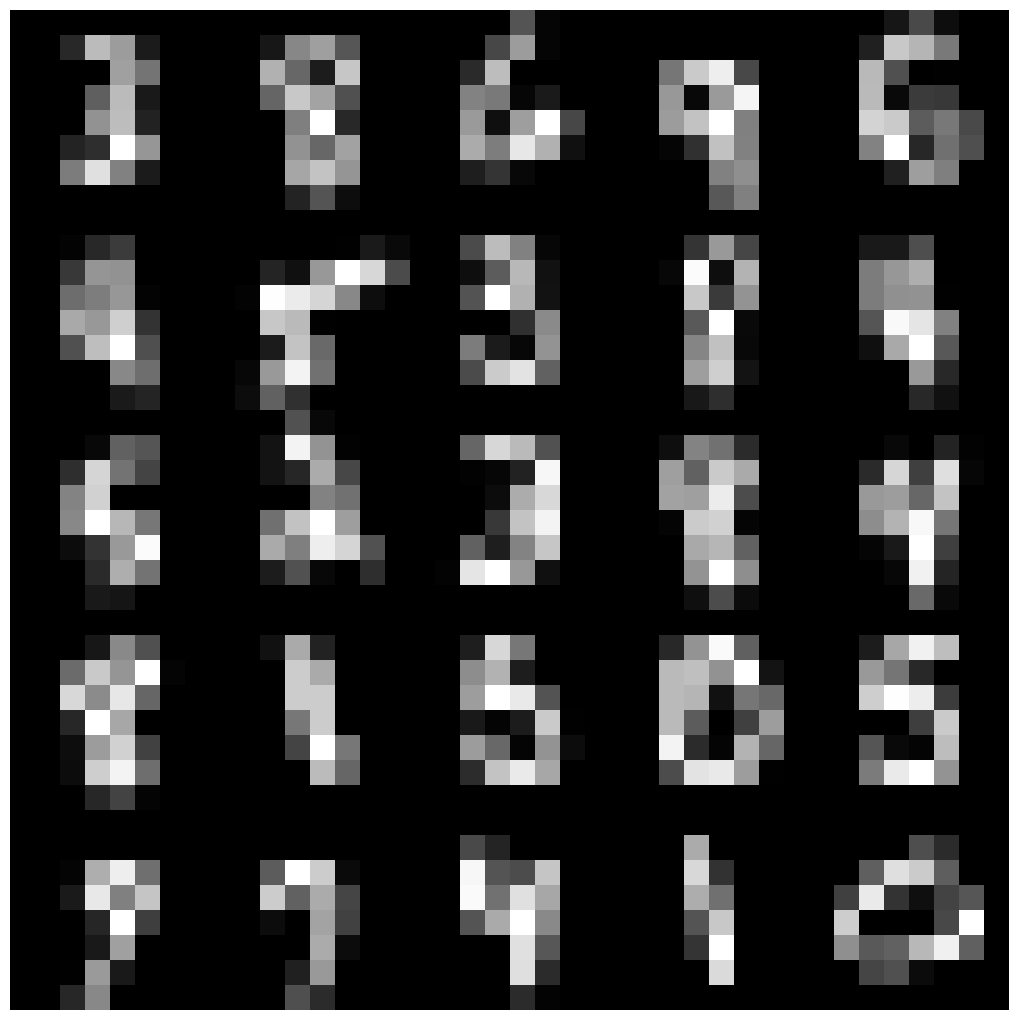

In [6]:
# show the true data (the target bitstring distributions, reshaped to images)
true_images = eval_dist[:25].reshape(-1, res, res)

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(true_images[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

The QeVAE latent is an ordinary Gaussian vector (unlike the density-matrix latent in `qvae.ipynb`), so
interpolation is the same linear walk in latent space used by `vae.ipynb`: encode two batches of images
to their posterior means and decode `(1-a) z1 + a z2` for `a` from 0 to 1.

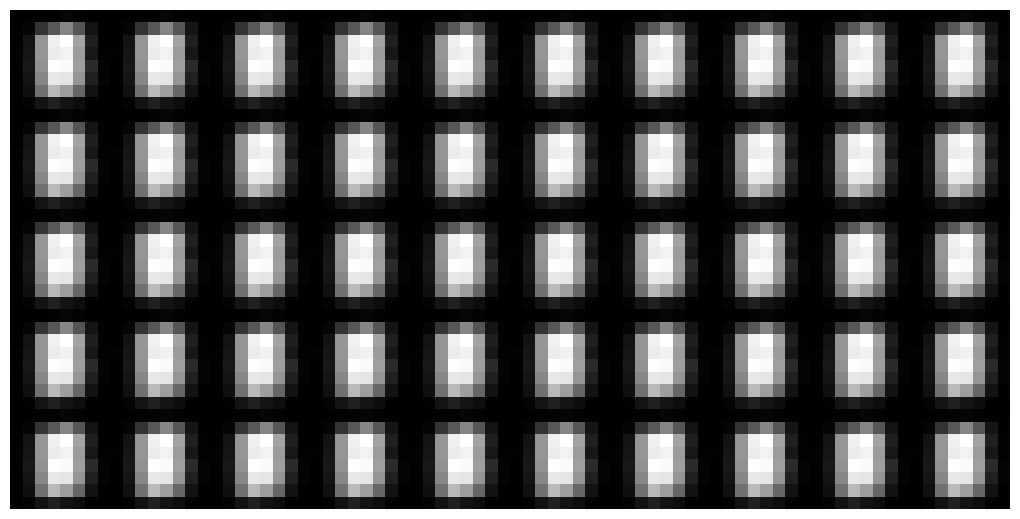

In [7]:
x1 = eval_marg[:5].to(device)
x2 = eval_marg[5:10].to(device)

with torch.no_grad():
    z1 = model.encode_mean(x1)
    z2 = model.encode_mean(x2)

    granularity = 10
    alphas = torch.linspace(0, 1, granularity, device=device)
    frames = [model.decode((1 - a) * z1 + a * z2) for a in alphas]
    interpolations = torch.stack(frames)  # (granularity, 5, 2^n)
    interpolations = dist_to_image(interpolations.reshape(-1, n_states))
    interpolations = interpolations.reshape(granularity, 5, res, res).permute(1, 0, 2, 3).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)